# <center> FTIR Image CNN Classifier </center>

## Google Colab / GPU setup

In [1]:
# Detect Colab if present
try:
    from google.colab import drive
    COLAB = True
    print('Note: using Google Colab')
except:
    print('Note: not using Google Colab')
    COLAB = False

# Use GPU or MPS (Apple) if available
import torch
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Note: not using Google Colab
Using device: mps


## FTIR Images Dataset

In [2]:
import os
from PIL import Image
from torch.utils.data import Dataset

# Dataset class to retrieve malignant and non-malignant FTIR images
class FTIRDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.data = []
        self.load_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path)
        return img, label
    
    def load_data(self):
        for label, sub_dir in enumerate(['non_malignant', 'malignant']):
            full_path = os.path.join(self.root_dir, sub_dir)
            images = [(os.path.join(full_path, img), label) for img in os.listdir(full_path) if img.endswith('.tif')]
            self.data.extend(images)
            

# Dataset: 50 FTIR core images total (40 malignant, 10 non-malignant)
full_dataset = FTIRDataset(root_dir='../dataset/ftir_core_all_images')
print(f'Dataset samples: {len(full_dataset)}')

Dataset samples: 50


## Augmentations

In [3]:
from torch.utils.data import DataLoader
from torchvision import transforms

IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
BATCH_SIZE = 8

# Augment training images (due to small set size)
def get_train_transform():
    train_transform = transforms.Compose([
        transforms.Resize((IMAGE_WIDTH, IMAGE_HEIGHT)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(90, fill=(0, 0, 0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_transform


# Test transform (no augmentation)
def get_test_transform():
    test_transform = transforms.Compose([
        transforms.Resize((IMAGE_WIDTH, IMAGE_HEIGHT)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return test_transform


# Applies augmentations to dataset (necessary to ensure training subset is augmented but not validation subset in cross-validation later)
class WrapperDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        
        if self.transform:
            img = self.transform(img)

        return img, label


augmented_dataset = WrapperDataset(base_dataset=full_dataset, transform=get_train_transform())
dataloader = DataLoader(augmented_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Check first batch as an example
for images, labels in dataloader:
    print(f'Batch shape: {images.shape}, Batch labels: {labels}')
    break

Batch shape: torch.Size([8, 3, 224, 224]), Batch labels: tensor([1, 1, 0, 1, 1, 1, 0, 0])


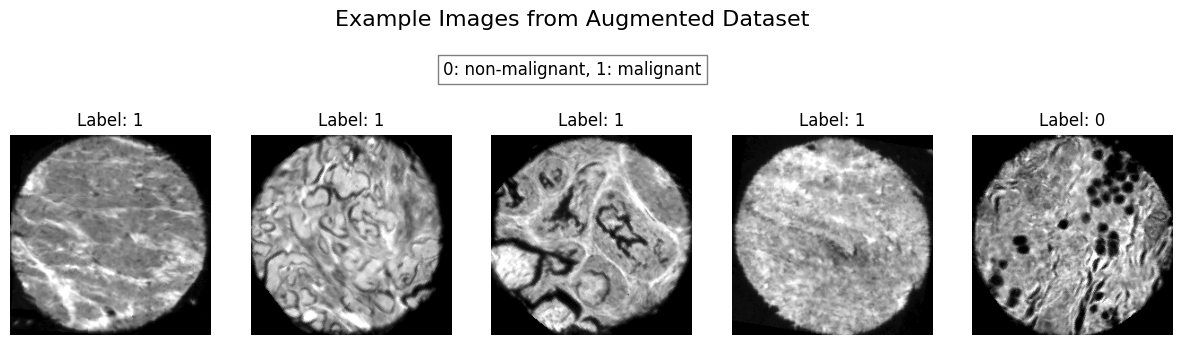

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Display random augmented images from the dataset 
def display_images(dataset, num_images=5, title=''):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    fig.suptitle(title, fontsize=16)
    fig.subplots_adjust(top=0.95)
    indices = random.sample(range(len(dataset)), num_images) 

    for i, ax in enumerate(axes):
        img, label = dataset[indices[i]]
        img = img.permute(1, 2, 0).numpy()
        img = img[:, :, 0] 

        ax.imshow(img, cmap='gray')
        ax.axis('off')
        ax.set_title(f'Label: {label}')

    legend_text = '0: non-malignant, 1: malignant'
    fig.text(0.5, 0.85, legend_text, ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()
    

display_images(augmented_dataset, title='Example Images from Augmented Dataset')

## Model Initialisation

A pretrained Resnet-18 model was used (with ImageNet weights) to achieve better results via transfer learning, due to the small dataset size (78 images total). 

Binary Cross-entropy loss function was used with class weights set to [0.9, 0.1] for non-malignant class(0) and malignant class (1) respectively, to deal with the class imbalance at the core level (65 malignant images and 13 non-malignant images).

In [7]:
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchvision import models
from torchvision.models import ResNet18_Weights

def init_model():
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(512, 128),
        nn.Dropout(0.5),
        nn.Linear(128, 2)
    )
        
    for name, param in model.named_parameters():
        if 'fc' in name: # unfreeze final layer
            param.requires_grad = True
        else:
            param.requires_grad = False
    
    model.to(device)
    return model

def init_optimiser(model, learning_rate=3e-4):
    optimiser = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    return optimiser

def init_loss_fn():
    weights = torch.tensor([0.85, 0.15]).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    return loss_fn


model = init_model()
summary(model, input_size=(8, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [8, 2]                    --
├─Conv2d: 1-1                            [8, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [8, 64, 112, 112]         (128)
├─ReLU: 1-3                              [8, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [8, 64, 56, 56]           --
├─Sequential: 1-5                        [8, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [8, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-2             [8, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [8, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [8, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [8, 64, 56, 56]   

## Training (Cross-validation)

The CNN model was trained on the full FTIR images dataset using 5-fold stratified cross validation. For each fold, the dataset was divided into a training subset and an independent validation subset.

In [8]:
from torch.utils.data import Subset


# Split dataset into training subset (augmented) and validation subset
def setup_data_loaders(train_id, val_id, dataset):
    train_transform = get_train_transform()
    val_transform = get_test_transform()
    
    train_subset = WrapperDataset(Subset(dataset, train_id), transform=train_transform)
    val_subset = WrapperDataset(Subset(dataset, val_id), transform=val_transform)
    
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader

In [9]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score


def train(train_loader, model, optimiser, loss_fn):
    model.train()
    epoch_loss = 0
    preds = []
    targets = []

    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # Forward pass
        y_batch_pred = model(x_batch)
        loss = loss_fn(y_batch_pred, y_batch)

        # Backward pass and optimisation (adam step)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_loss += loss.item()

        _, batch_pred = torch.max(y_batch_pred, 1)
        preds.extend(batch_pred.cpu().numpy())
        targets.extend(y_batch.cpu().numpy())
        

    avg_loss = epoch_loss / len(train_loader)
    accuracy = accuracy_score(targets, preds)
    return avg_loss, accuracy

def validate(val_loader, model, loss_fn):
    model.eval()
    total_loss = 0
    val_preds = []
    val_probs = []
    val_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            val_labels.extend(labels.cpu().numpy())

            _, batch_pred = torch.max(outputs, 1)
            val_preds.extend(batch_pred.cpu().numpy())
            
            probabilities = F.softmax(outputs, dim=1)
            val_probs.extend(probabilities[:, 1].cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(val_labels, val_preds)
    return avg_loss, accuracy, val_probs, val_labels

In [10]:
from sklearn.metrics import auc, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm

num_epochs = 30
num_folds = 5
kf = StratifiedKFold(num_folds, shuffle=True)
labels = [label for _, label in full_dataset.data]

all_train_losses = []
all_val_losses = []
all_val_probs = []
all_val_labels = []

fold_val_aucs = []
fold_val_accuracies = []
fold_val_precisions = []
fold_val_recalls = []
fold_val_f1_scores = []

# 5-fold stratified cross validation
for fold, (train_id, val_id) in enumerate(kf.split(np.zeros(len(labels)), labels)):
    train_loader, val_loader = setup_data_loaders(train_id, val_id, full_dataset)
    model = init_model()
    optimiser = init_optimiser(model)
    loss_fn = init_loss_fn()

    fold_train_losses = []
    fold_val_losses = []

    with tqdm(total=num_epochs, desc=f'Fold {fold + 1}/{num_folds}', position=0, leave=True) as pbar:
        for epoch in range(num_epochs):
            train_loss, train_acc = train(train_loader, model, optimiser, loss_fn)
            val_loss, val_acc, val_probs, val_labels = validate(val_loader, model, loss_fn)

            # Store metrics for the fold (final epoch)
            if epoch == num_epochs - 1:
                val_preds = [1 if p > 0.5 else 0 for p in val_probs]
                val_auc = roc_auc_score(val_labels, val_probs)
                val_precision = precision_score(val_labels, val_preds)
                val_recall = recall_score(val_labels, val_preds)
                val_f1 = f1_score(val_labels, val_preds)

                fold_val_accuracies.append(val_acc)
                fold_val_aucs.append(val_auc)
                fold_val_precisions.append(val_precision)
                fold_val_recalls.append(val_recall)
                fold_val_f1_scores.append(val_f1)
            
            fold_train_losses.append(train_loss)
            fold_val_losses.append(val_loss)
            
            print(f'Epoch [{epoch + 1}/{num_epochs}]\nTrain Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}' \
                  f'\nTrain Acc: {train_acc * 100:.2f}%, Val Acc: {val_acc * 100:.2f}%\n')
            pbar.update(1)

    all_train_losses.append(fold_train_losses)
    all_val_losses.append(fold_val_losses)
    all_val_probs.append(val_probs)
    all_val_labels.append(val_labels)

Fold 1/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.6803, Val Loss: 0.5073
Train Acc: 62.50%, Val Acc: 80.00%

Epoch [2/30]
Train Loss: 0.7036, Val Loss: 0.4477
Train Acc: 62.50%, Val Acc: 100.00%

Epoch [3/30]
Train Loss: 0.5897, Val Loss: 0.4351
Train Acc: 70.00%, Val Acc: 100.00%

Epoch [4/30]
Train Loss: 0.5127, Val Loss: 0.3864
Train Acc: 77.50%, Val Acc: 100.00%

Epoch [5/30]
Train Loss: 0.6366, Val Loss: 0.3818
Train Acc: 65.00%, Val Acc: 100.00%

Epoch [6/30]
Train Loss: 0.5117, Val Loss: 0.3392
Train Acc: 60.00%, Val Acc: 100.00%

Epoch [7/30]
Train Loss: 0.4798, Val Loss: 0.3235
Train Acc: 80.00%, Val Acc: 100.00%

Epoch [8/30]
Train Loss: 0.4129, Val Loss: 0.3011
Train Acc: 75.00%, Val Acc: 90.00%

Epoch [9/30]
Train Loss: 0.4585, Val Loss: 0.2660
Train Acc: 82.50%, Val Acc: 100.00%

Epoch [10/30]
Train Loss: 0.4343, Val Loss: 0.2405
Train Acc: 90.00%, Val Acc: 100.00%

Epoch [11/30]
Train Loss: 0.4091, Val Loss: 0.2335
Train Acc: 92.50%, Val Acc: 90.00%

Epoch [12/30]
Train Loss: 0.4779, Val Loss: 

Fold 2/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.7854, Val Loss: 0.7037
Train Acc: 72.50%, Val Acc: 40.00%

Epoch [2/30]
Train Loss: 0.7293, Val Loss: 0.7563
Train Acc: 50.00%, Val Acc: 30.00%

Epoch [3/30]
Train Loss: 0.7066, Val Loss: 0.8324
Train Acc: 45.00%, Val Acc: 30.00%

Epoch [4/30]
Train Loss: 0.7167, Val Loss: 0.9435
Train Acc: 47.50%, Val Acc: 20.00%

Epoch [5/30]
Train Loss: 0.5918, Val Loss: 0.8141
Train Acc: 55.00%, Val Acc: 30.00%

Epoch [6/30]
Train Loss: 0.6364, Val Loss: 0.5352
Train Acc: 70.00%, Val Acc: 80.00%

Epoch [7/30]
Train Loss: 0.6003, Val Loss: 0.5260
Train Acc: 82.50%, Val Acc: 60.00%

Epoch [8/30]
Train Loss: 0.6890, Val Loss: 0.5033
Train Acc: 52.50%, Val Acc: 70.00%

Epoch [9/30]
Train Loss: 0.6027, Val Loss: 0.4434
Train Acc: 77.50%, Val Acc: 90.00%

Epoch [10/30]
Train Loss: 0.3738, Val Loss: 0.4214
Train Acc: 80.00%, Val Acc: 80.00%

Epoch [11/30]
Train Loss: 0.5780, Val Loss: 0.3977
Train Acc: 57.50%, Val Acc: 70.00%

Epoch [12/30]
Train Loss: 0.4709, Val Loss: 0.3889
T

Fold 3/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.5989, Val Loss: 0.6258
Train Acc: 57.50%, Val Acc: 80.00%

Epoch [2/30]
Train Loss: 0.6688, Val Loss: 0.7106
Train Acc: 62.50%, Val Acc: 40.00%

Epoch [3/30]
Train Loss: 0.5482, Val Loss: 0.6398
Train Acc: 65.00%, Val Acc: 60.00%

Epoch [4/30]
Train Loss: 0.6279, Val Loss: 0.7076
Train Acc: 75.00%, Val Acc: 20.00%

Epoch [5/30]
Train Loss: 0.6118, Val Loss: 0.6014
Train Acc: 75.00%, Val Acc: 70.00%

Epoch [6/30]
Train Loss: 0.5520, Val Loss: 0.7371
Train Acc: 60.00%, Val Acc: 20.00%

Epoch [7/30]
Train Loss: 0.5842, Val Loss: 0.6047
Train Acc: 55.00%, Val Acc: 70.00%

Epoch [8/30]
Train Loss: 0.5256, Val Loss: 0.5625
Train Acc: 72.50%, Val Acc: 70.00%

Epoch [9/30]
Train Loss: 0.5135, Val Loss: 0.4071
Train Acc: 72.50%, Val Acc: 90.00%

Epoch [10/30]
Train Loss: 0.5241, Val Loss: 0.4592
Train Acc: 87.50%, Val Acc: 80.00%

Epoch [11/30]
Train Loss: 0.3646, Val Loss: 0.5090
Train Acc: 92.50%, Val Acc: 80.00%

Epoch [12/30]
Train Loss: 0.4575, Val Loss: 0.5567
T

Fold 4/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.8418, Val Loss: 0.9874
Train Acc: 20.00%, Val Acc: 20.00%

Epoch [2/30]
Train Loss: 0.7551, Val Loss: 0.9534
Train Acc: 42.50%, Val Acc: 20.00%

Epoch [3/30]
Train Loss: 0.5968, Val Loss: 0.9133
Train Acc: 65.00%, Val Acc: 20.00%

Epoch [4/30]
Train Loss: 0.5566, Val Loss: 0.7838
Train Acc: 72.50%, Val Acc: 30.00%

Epoch [5/30]
Train Loss: 0.5978, Val Loss: 0.7791
Train Acc: 77.50%, Val Acc: 30.00%

Epoch [6/30]
Train Loss: 0.5870, Val Loss: 0.7204
Train Acc: 75.00%, Val Acc: 30.00%

Epoch [7/30]
Train Loss: 0.5022, Val Loss: 0.7799
Train Acc: 75.00%, Val Acc: 30.00%

Epoch [8/30]
Train Loss: 0.4554, Val Loss: 0.8266
Train Acc: 72.50%, Val Acc: 30.00%

Epoch [9/30]
Train Loss: 0.5125, Val Loss: 0.6578
Train Acc: 82.50%, Val Acc: 50.00%

Epoch [10/30]
Train Loss: 0.3615, Val Loss: 0.6955
Train Acc: 87.50%, Val Acc: 40.00%

Epoch [11/30]
Train Loss: 0.3389, Val Loss: 0.7169
Train Acc: 87.50%, Val Acc: 50.00%

Epoch [12/30]
Train Loss: 0.3594, Val Loss: 0.7312
T

Fold 5/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.9577, Val Loss: 0.7391
Train Acc: 72.50%, Val Acc: 40.00%

Epoch [2/30]
Train Loss: 0.8630, Val Loss: 1.0138
Train Acc: 30.00%, Val Acc: 20.00%

Epoch [3/30]
Train Loss: 0.7557, Val Loss: 0.7046
Train Acc: 30.00%, Val Acc: 30.00%

Epoch [4/30]
Train Loss: 0.6901, Val Loss: 0.6343
Train Acc: 65.00%, Val Acc: 80.00%

Epoch [5/30]
Train Loss: 0.7197, Val Loss: 0.6728
Train Acc: 65.00%, Val Acc: 50.00%

Epoch [6/30]
Train Loss: 0.6604, Val Loss: 0.7335
Train Acc: 55.00%, Val Acc: 40.00%

Epoch [7/30]
Train Loss: 0.5853, Val Loss: 0.7157
Train Acc: 67.50%, Val Acc: 50.00%

Epoch [8/30]
Train Loss: 0.5389, Val Loss: 0.5749
Train Acc: 65.00%, Val Acc: 90.00%

Epoch [9/30]
Train Loss: 0.6110, Val Loss: 0.5348
Train Acc: 70.00%, Val Acc: 90.00%

Epoch [10/30]
Train Loss: 0.4693, Val Loss: 0.5108
Train Acc: 90.00%, Val Acc: 80.00%

Epoch [11/30]
Train Loss: 0.5882, Val Loss: 0.4889
Train Acc: 70.00%, Val Acc: 80.00%

Epoch [12/30]
Train Loss: 0.5637, Val Loss: 0.4423
T

## Results

In [11]:
def output_stats(name, array):
    mean = np.mean(array)
    std = np.std(array)
    print(f'{name:<25} Mean: {mean:.4f} ± {std:.4f}')

print('Metrics (across 5 folds):')
print('-' * 48)
output_stats('Accuracies', fold_val_accuracies)
output_stats('AUCs', fold_val_aucs)
output_stats('Precisions', fold_val_precisions)
output_stats('Recalls', fold_val_recalls)
output_stats('F1 Scores', fold_val_f1_scores)

Metrics (across 5 folds):
------------------------------------------------
Accuracies                Mean: 0.7400 ± 0.1020
AUCs                      Mean: 0.8750 ± 0.1723
Precisions                Mean: 0.9667 ± 0.0667
Recalls                   Mean: 0.7000 ± 0.1000
F1 Scores                 Mean: 0.8086 ± 0.0773


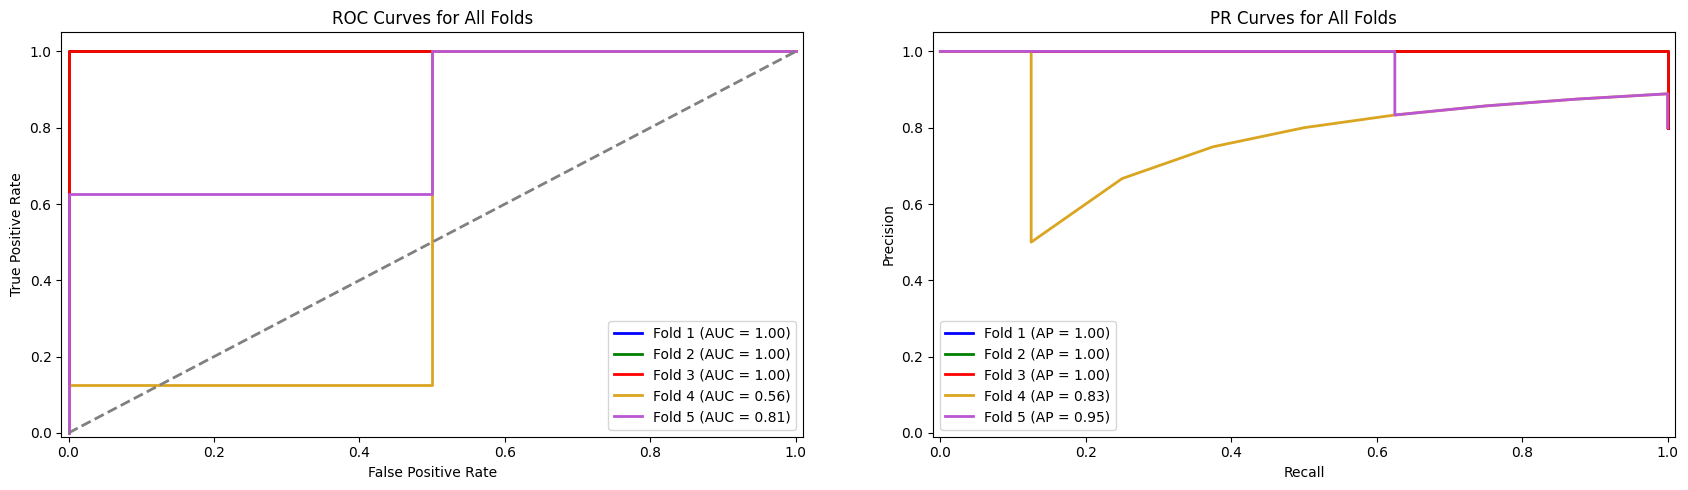

In [12]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score


def plot_roc_pr_curves(fold_val_patch_probs, fold_val_patch_labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    colors = ['blue', 'green', 'red', 'goldenrod', 'mediumorchid']

    # ROC Curves for each fold
    for fold in range(len(fold_val_patch_probs)):
        fpr, tpr, _ = roc_curve(fold_val_patch_labels[fold], fold_val_patch_probs[fold])
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color=colors[fold], lw=2, 
                 label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')

    ax1.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    ax1.set_xlim([-0.01, 1.01])
    ax1.set_ylim([-0.01, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curves for All Folds')
    ax1.legend(loc='lower right')

    # PR Curves for each fold
    for fold in range(len(fold_val_patch_probs)):
        precision, recall, _ = precision_recall_curve(fold_val_patch_labels[fold], fold_val_patch_probs[fold])
        avg_prec = average_precision_score(fold_val_patch_labels[fold], fold_val_patch_probs[fold])
        ax2.plot(recall, precision, color=colors[fold], lw=2,
                 label=f'Fold {fold+1} (AP = {avg_prec:.2f})')

    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'PR Curves for All Folds')
    ax2.set_xlim([-0.01, 1.01])
    ax2.set_ylim([-0.01, 1.05])
    ax2.legend(loc='lower left')
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.175)
    plt.show()


plot_roc_pr_curves(all_val_probs, all_val_labels)

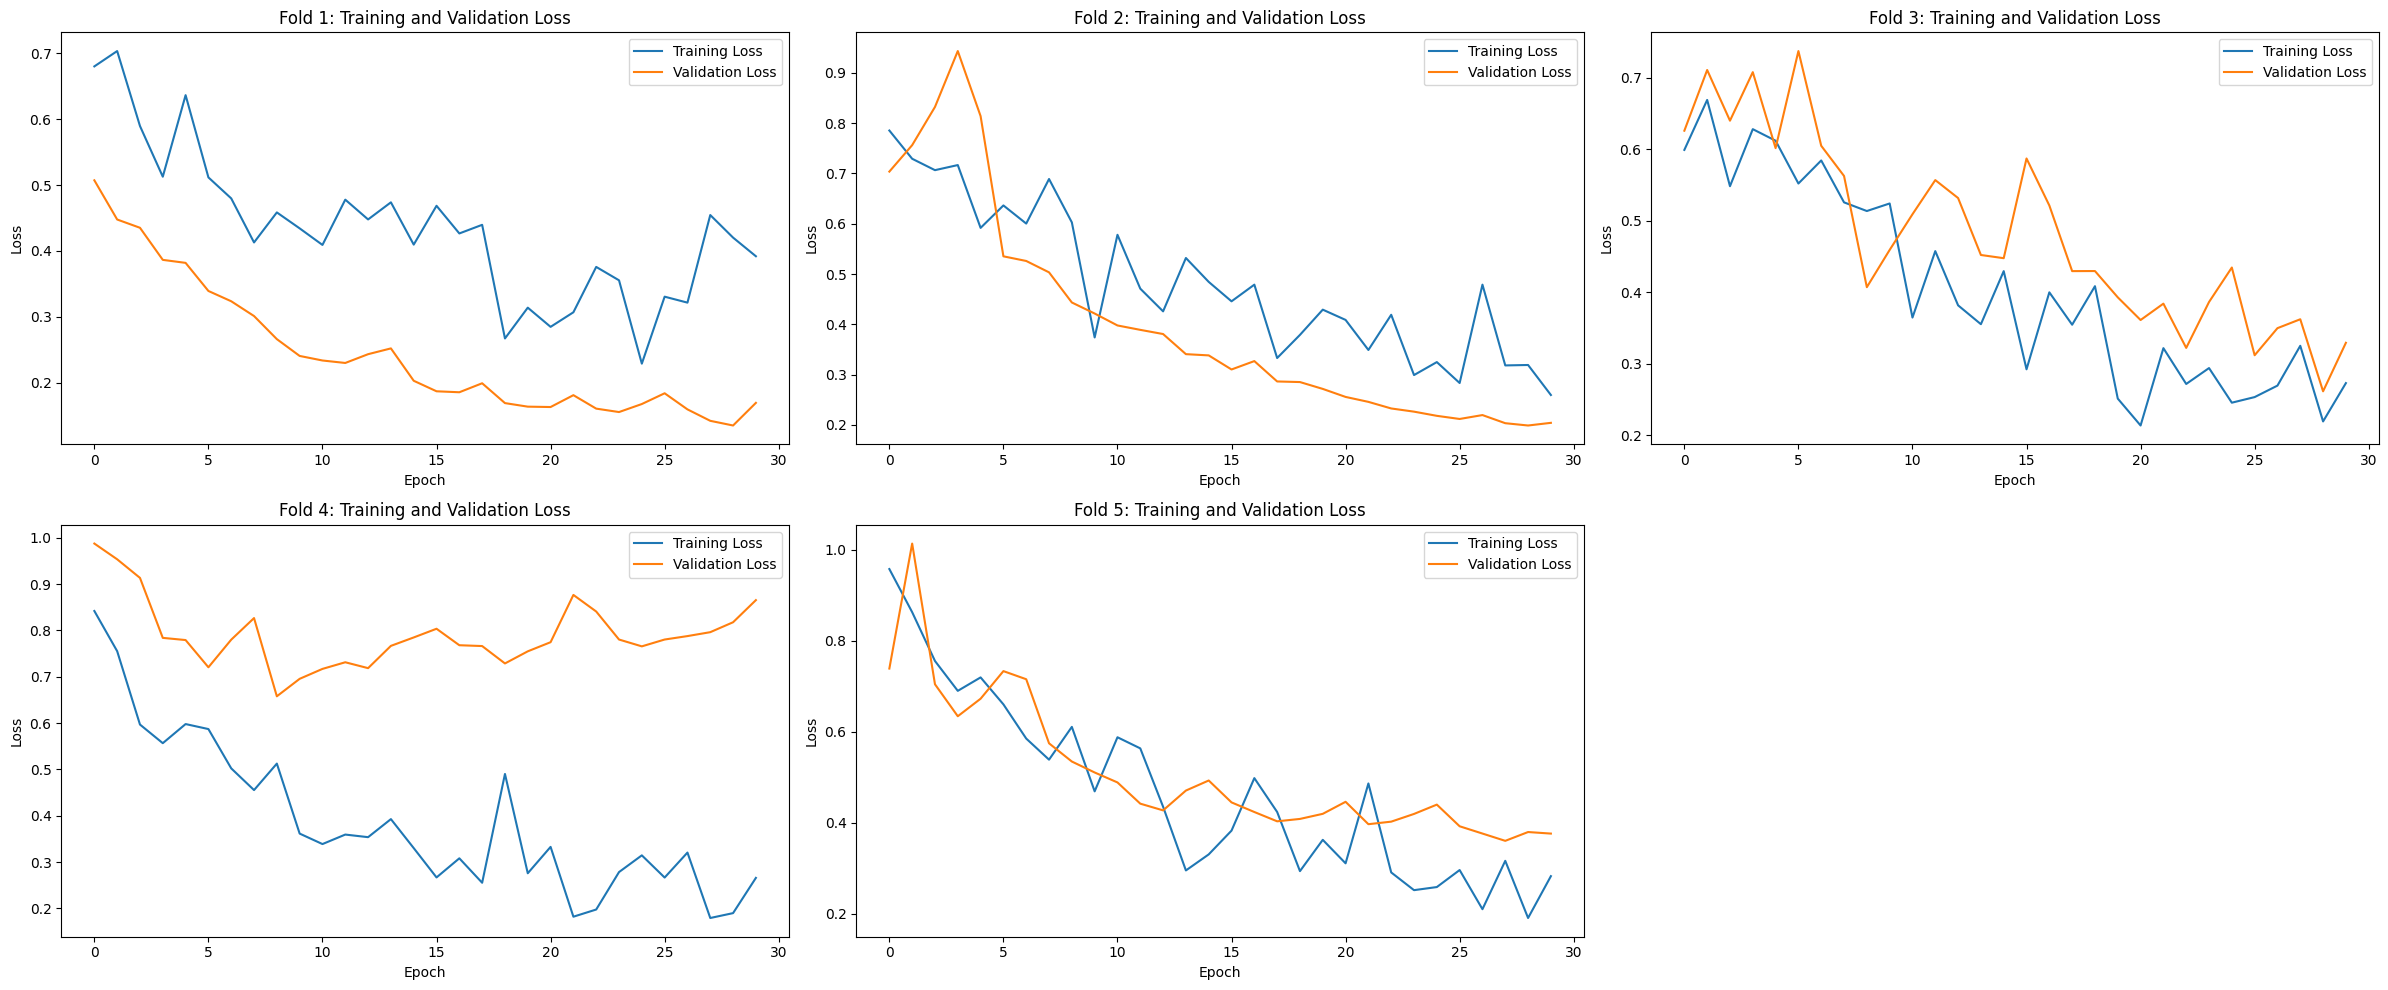

In [13]:
# Plot train and validation losses for each fold
def plot_losses(fold_num, train_losses, val_losses, ax):
    ax.plot(train_losses, label='Training Loss')
    ax.plot(val_losses, label='Validation Loss')
    ax.set_title(f'Fold {fold_num}: Training and Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

fig, axes = plt.subplots(2, 3, figsize=(24, 10)) 

for fold in range(num_folds):
    row = fold // 3 
    col = fold % 3  
    ax = axes[row, col]
    plot_losses(fold + 1, all_train_losses[fold], all_val_losses[fold], ax)

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()